In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\3_comp
scenario=3comp_equal  K_MODEL=5  K_TRUE=3
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)
  replication mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth, Grids (Full + Chebyshev) & Trimmed Mass ──────────
# Two grids per parameter, used by all cells below; the True DGP only enters the
# envelopes and stays an overlay in the plots.
#   "Full"      - min/max envelope over every component of every sampler + True
#                 DGP; nothing excluded, can be very wide.
#   "Chebyshev" - each model's pooled-marginal mean +/- 5*std (exact moments via
#                 the law of total variance), so >= 96% of each model's marginal
#                 mass is guaranteed inside for any distribution.
# Trimmed-mass tables report the realised trim EXACTLY (mixture CDF, no grid
# error) - equal to the renormalisation each density receives in Cell 5. The
# window is symmetric in x, not in mass: the left/right split shows the skew.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

for label, grids in GRIDS.items():
    trimmed = {m["name"]: (1.0 - mc.retained_mass(m, grids)) * 100.0
               for m in models + [true_model]}
    print(f"\nMass trimmed by the [{label}] window, in % of each marginal:")
    display(pd.DataFrame(trimmed, index=param_names).T.round(4))

cheb = GRIDS["Chebyshev (k=5, >=96%)"]
split = {}
for m in models + [true_model]:
    l, r = mc.trimmed_tails(m, cheb)
    split[m["name"]] = np.r_[l, r] * 100.0
cols = pd.MultiIndex.from_product([["left tail", "right tail"], param_names])
print("\nChebyshev trim by side, in % of each marginal:")
display(pd.DataFrame(split, index=cols).T.round(4))

Grid extents [Full]:
  Alt1       [-741.00, +605.11]
  Alt2       [-472.27, +599.88]
  Alt3       [-1178.43, +680.22]
  Price      [-247.07, +308.45]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-8.71, +14.41]
  Alt2       [-16.31, +17.32]
  Alt3       [-9.25, +14.17]
  Price      [-19.86, +12.28]

Mass trimmed by the [Full] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0,0.0,0.0,0.0
HMC,0.0,0.0,0.0,0.0
NUTS,0.0,0.0,0.0,0.0
replication,0.0,0.0,0.0,0.0
True DGP,0.0,0.0,0.0,0.0



Mass trimmed by the [Chebyshev (k=5, >=96%)] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0317,0.0085,0.0280,0.0123
HMC,0.1967,0.0640,0.0740,0.0224
NUTS,0.2090,0.0776,0.1129,0.0288
replication,0.0781,0.0126,0.0612,0.0164
True DGP,0.0000,0.0000,0.0000,0.0000



Chebyshev trim by side, in % of each marginal:


left tail                         right tail                  \
                 Alt1    Alt2    Alt3   Price       Alt1    Alt2    Alt3   
bayesm         0.0200  0.0047  0.0199  0.0028     0.0117  0.0038  0.0081   
HMC            0.0937  0.0205  0.0426  0.0070     0.1029  0.0435  0.0314   
NUTS           0.0768  0.0308  0.0851  0.0070     0.1322  0.0467  0.0277   
replication    0.0225  0.0083  0.0521  0.0076     0.0556  0.0043  0.0091   
True DGP       0.0000  0.0000  0.0000  0.0000     0.0000  0.0000  0.0000   

                     
              Price  
bayesm       0.0095  
HMC          0.0154  
NUTS         0.0219  
replication  0.0088  
True DGP     0.0000

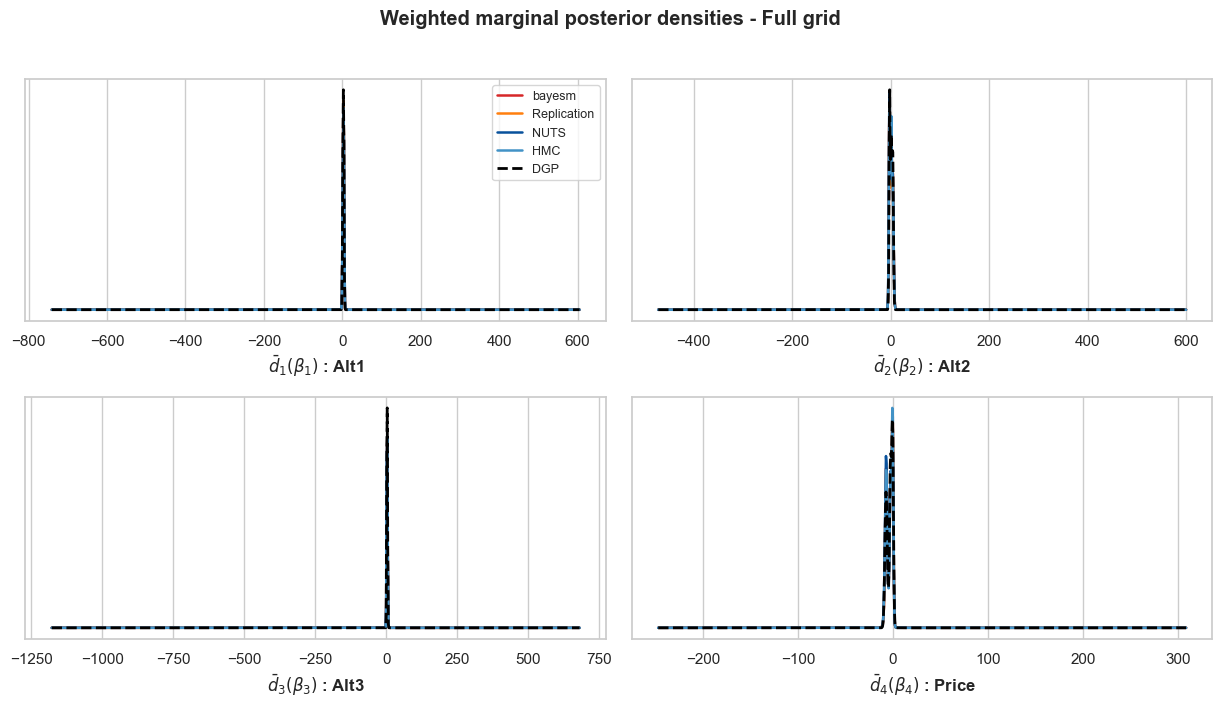

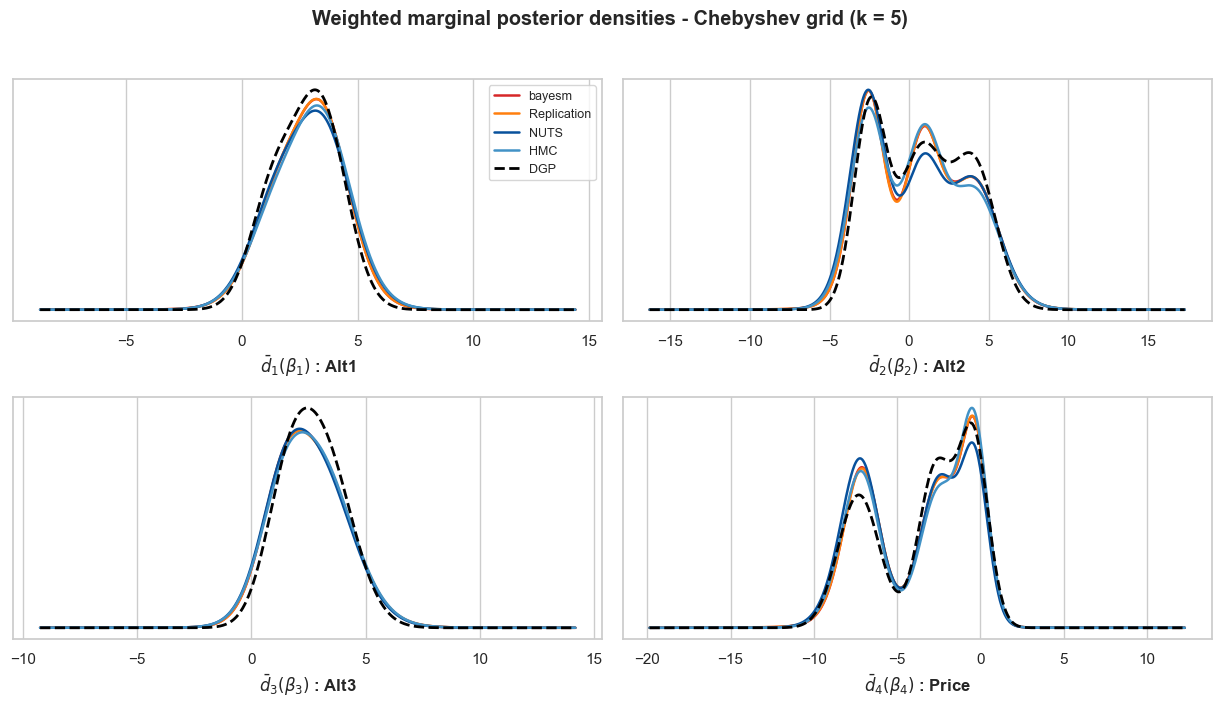

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev ──────────
# One figure per grid pass. Legend order: bayesm, Replication, NUTS, HMC, DGP.
# DGP dashed black, bayesm red, Replication orange, NUTS/HMC in blues.
# Densities are cached in DENS/DENS_TRUE and reused by Cell 5.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "bayesm": "#d62728", "replication": "#ff7f0e"}
TRUE_COLOR = "#000000"
LEGEND_ORDER = ["bayesm", "replication", "NUTS", "HMC"]
DISPLAY_NAME = {"NUTS": "NUTS", "HMC": "HMC", "bayesm": "bayesm", "replication": "Replication"}
TITLE_SUFFIX = {"Full": "Full grid", "Chebyshev (k=5, >=96%)": "Chebyshev grid (k = 5)"}
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.6), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name in LEGEND_ORDER:
            if name not in dens:
                continue
            ax[j].plot(grids[j], dens[name][j], lw=1.8, label=DISPLAY_NAME[name],
                       color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="DGP")
        ax[j].set_xlabel(rf"$\bar{{d}}_{{{j+1}}}(\beta_{{{j+1}}})$ : {pj}", fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Weighted marginal posterior densities - {TITLE_SUFFIX.get(label, label)}",
                 fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev ──────────
# Each sampler vs the True DGP only (never sampler-vs-sampler): KL(model||true)
# and TVD. Reuses DENS/DENS_TRUE.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:258: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


KL      TVD
sampler     param              
bayesm      Alt1   inf  0.04839
            Alt2   inf  0.06245
            Alt3   inf  0.06898
            Price  inf  0.05619
HMC         Alt1   inf  0.06910
            Alt2   inf  0.06892
            Alt3   inf  0.06300
            Price  inf  0.05661
NUTS        Alt1   inf  0.05977
            Alt2   inf  0.07635
            Alt3   inf  0.07690
            Price  inf  0.07736
replication Alt1   inf  0.04819
            Alt2   inf  0.06423
            Alt3   inf  0.06954
            Price  inf  0.05610

--- Chebyshev (k=5, >=96%) ---


KL      TVD
sampler     param                  
bayesm      Alt1   0.04311  0.05074
            Alt2   0.03920  0.06378
            Alt3   0.03872  0.07163
            Price  0.03147  0.05650
HMC         Alt1   0.06353  0.07276
            Alt2   0.05784  0.06829
            Alt3   0.04882  0.07156
            Price  0.03025  0.05633
NUTS        Alt1   0.05906  0.06453
            Alt2   0.06621  0.07734
            Alt3   0.05353  0.07755
            Price  0.04113  0.07715
replication Alt1   0.04865  0.05000
            Alt2   0.05114  0.06567
            Alt3   0.04430  0.07322
            Price  0.03948  0.05647

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent (analytic in the draws); runs once.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.824,2.899,2.847,2.841,2.719
Alt2,0.623,0.577,0.505,0.622,0.781
Alt3,2.517,2.533,2.461,2.514,2.635
Price,-3.606,-3.576,-3.894,-3.612,-3.454


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.665,4.176,5.302,2.926,2.072
Alt2,9.795,10.354,11.251,9.897,8.600
Alt3,2.725,3.016,5.438,2.892,1.993
Price,9.697,10.020,10.106,9.782,9.352


In [7]:
# ── Cell 7 : Convergence of the Marginals - Goose-identical functional diagnostics ──────────
# az.rhat (rank) / az.ess (bulk, tail) - the exact calls in Goose's summary() -
# on grid-free functionals of each per-draw marginal: mean, sd, q05/q50/q95.
# ESS/s divides by the fit's total wall-clock (meta.json duration_s, incl.
# warmup). Read ESS only where R-hat ~ 1. Alternatives: mc.curve_diagnostics,
# mc.density_series_diagnostics.
if CHAINS == 1:
    print("NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.\n")

for m in models:
    rt = m.get("duration_s")
    print(f"--- {m['name']}" + (f"  (fit wall-clock: {rt:,.0f}s)" if rt else "") + " ---")
    display(mc.functional_diagnostics(m, param_names).round(3))

--- bayesm  (fit wall-clock: 433s) ---


Rhat  ESS_bulk   ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                    
Alt1  mean        1.004   760.917   2666.071       1.757       6.157
      sd          1.005   983.532   3192.009       2.271       7.372
      q05         1.001  1541.742   3629.791       3.561       8.383
      q50         1.004   980.866   3034.452       2.265       7.008
      q95         1.007   628.745   1710.421       1.452       3.950
Alt2  mean        1.001  1245.020   4793.153       2.875      11.070
      sd          1.002   700.812    986.626       1.619       2.279
      q05         1.009   274.791    160.830       0.635       0.371
      q50         1.001   973.254   2304.770       2.248       5.323
      q95         1.001   739.409   1385.028       1.708       3.199
Alt3  mean        1.001  1199.122   3901.840       2.769       9.011
      sd          1.001  1114.392   2816.126       2.574       6.504
      q05         1.001  2022.872   4763.700       4.672      11.002
      q50         1.004   968.118   3641.676       2.236       8.410
      q95         1.001   748.020   1788.633       1.728       4.131
Price mean        1.005   667.832   1559.324       1.542       3.601
      sd          1.018   160.274    129.279       0.370       0.299
      q05         1.019   128.416     81.332       0.297       0.188
      q50         1.000  6097.803  13941.827      14.083      32.198
      q95         1.000  8673.051  14401.397      20.030      33.260

--- HMC  (fit wall-clock: 440s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.027   123.963   238.590       0.282       0.542
      sd          1.194     7.784    55.244       0.018       0.125
      q05         1.021   617.303  2714.911       1.402       6.167
      q50         1.054    30.043   622.852       0.068       1.415
      q95         1.001   401.596   917.332       0.912       2.084
Alt2  mean        1.072    23.172    45.648       0.053       0.104
      sd          1.206     6.907    51.809       0.016       0.118
      q05         1.015   329.364  1149.511       0.748       2.611
      q50         1.020   337.981   570.969       0.768       1.297
      q95         1.039   194.689   760.810       0.442       1.728
Alt3  mean        1.009   622.841  1751.274       1.415       3.978
      sd          1.111    14.102   121.661       0.032       0.276
      q05         1.011   679.480  3227.772       1.544       7.333
      q50         1.004   739.844  2433.875       1.681       5.529
      q95         1.015   340.454  1301.270       0.773       2.956
Price mean        1.064    22.863    49.632       0.052       0.113
      sd          1.010   313.981   962.821       0.713       2.187
      q05         1.016   191.023   688.362       0.434       1.564
      q50         1.103    12.658    42.897       0.029       0.097
      q95         1.018   156.128  2422.853       0.355       5.504

--- NUTS  (fit wall-clock: 4,330s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.059    31.976    75.548       0.007       0.017
      sd          1.127    11.157   129.707       0.003       0.030
      q05         1.006  1291.519  2553.446       0.298       0.590
      q50         1.055    31.480   818.914       0.007       0.189
      q95         1.059    31.934   838.433       0.007       0.194
Alt2  mean        1.197     7.246    45.391       0.002       0.010
      sd          1.018   561.241   280.367       0.130       0.065
      q05         1.007   791.265  2233.793       0.183       0.516
      q50         1.350     4.696    72.021       0.001       0.017
      q95         1.001   947.316  2099.895       0.219       0.485
Alt3  mean        1.096    15.198    67.073       0.004       0.015
      sd          1.067    21.419   123.684       0.005       0.029
      q05         1.006  1182.145  2309.784       0.273       0.533
      q50         1.175     8.315    97.731       0.002       0.023
      q95         1.045    42.715   996.894       0.010       0.230
Price mean        1.651     3.225    42.947       0.001       0.010
      sd          1.029   138.554   655.933       0.032       0.151
      q05         1.003   521.586  1213.821       0.120       0.280
      q50         1.724     3.056    41.751       0.001       0.010
      q95         1.285     5.246    50.143       0.001       0.012

--- replication  (fit wall-clock: 334s) ---


Rhat  ESS_bulk   ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                    
Alt1  mean        1.004   490.828    870.516       1.468       2.604
      sd          1.017    88.079     28.859       0.263       0.086
      q05         1.002  1557.680   4667.792       4.660      13.963
      q50         1.002  1086.539   3342.167       3.250       9.998
      q95         1.005   417.438    455.428       1.249       1.362
Alt2  mean        1.009  1177.207   4644.548       3.521      13.893
      sd          1.003   522.082    643.664       1.562       1.925
      q05         1.033   136.314     87.662       0.408       0.262
      q50         1.006   753.851   2505.188       2.255       7.494
      q95         1.014   417.663    718.409       1.249       2.149
Alt3  mean        1.014   226.700    450.328       0.678       1.347
      sd          1.023    91.863     39.746       0.275       0.119
      q05         1.003  1743.966   4554.806       5.217      13.625
      q50         1.002  1344.772   3663.098       4.023      10.958
      q95         1.007   456.014    601.598       1.364       1.800
Price mean        1.005  1029.495   2660.337       3.080       7.958
      sd          1.023   182.959    353.609       0.547       1.058
      q05         1.030   106.019     87.305       0.317       0.261
      q50         1.000  4694.174  10179.738      14.042      30.451
      q95         1.001  8744.338  15718.368      26.157      47.019

In [8]:
# ── Cell 8 : Notes ──────────
print("Notes:")
print(" - All quantities are label-invariant: relabeling/ECR would not change them.")
print(" - Grids: 'Full' = unbounded envelope over every component + True DGP;")
print("   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).")
print(" - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail")
print("   ESS) on grid-free functionals of each per-draw marginal.")
print(" - 1-chain runs: chains split into halves - a within-chain check only.")
print("   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).")

Notes:
 - All quantities are label-invariant: relabeling/ECR would not change them.
 - Grids: 'Full' = unbounded envelope over every component + True DGP;
   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).
 - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail
   ESS) on grid-free functionals of each per-draw marginal.
 - 1-chain runs: chains split into halves - a within-chain check only.
   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).
